### Генерация синтетических документов и сплит (train/test)

Этот ноутбук генерирует синтетические документы (PDF→PNG+JSON) и раскладывает их в `data/train` и `data/test`.
- Конфиг: `config.example.json` (секции `llm`, `generator`, `augment`, `layout`).
- Артефакты: подписи/печати в `assets/signatures/png`, `assets/stamps/png`.
- Выход: `data/train`, `data/test` с парами `*.png` + `*.json`.



In [13]:
%%capture
# Опционально: установка зависимостей генератора
%pip install --quiet faker reportlab pdf2image albumentations pillow numpy huggingface_hub
# Для vLLM-режима генерации текста (опционально)
# %pip install --quiet vllm



In [14]:
# Параметры генерации и путей
from pathlib import Path

CONFIG_PATH = Path("config.example.json")
TRAIN_OUT = Path("data/train")
TEST_OUT  = Path("data/test")
TRAIN_N = 1000
TEST_N  = 100
BATCH_SIZE = 8            # батчинг запросов к LLM (vLLM) / параллельные openai-запросы
RENDER_WORKERS = 4        # число процессов для рендера PDF→PNG+JSON (CPU)

print("CONFIG:", CONFIG_PATH.resolve())
print("TRAIN_OUT:", TRAIN_OUT.resolve())
print("TEST_OUT:", TEST_OUT.resolve())
print("N:", TRAIN_N, TEST_N)
print("BATCH_SIZE:", BATCH_SIZE)



CONFIG: /home/user/workspace/re-synthetic-docs/config.example.json
TRAIN_OUT: /home/user/workspace/re-synthetic-docs/data/train
TEST_OUT: /home/user/workspace/re-synthetic-docs/data/test
N: 1000 100
BATCH_SIZE: 8


In [15]:
# Загрузка конфига и краткое отображение ключевых параметров
import json
cfg = json.loads(Path(CONFIG_PATH).read_text(encoding="utf-8"))

print("LLM:", cfg.get("llm", {}))
print("GENERATOR:", cfg.get("generator", {}))
print("AUGMENT:", cfg.get("augment", {}))
print("LAYOUT:", cfg.get("layout", {}))



LLM: {'mode': 'openai', 'base_url': 'http://localhost:8000/v1', 'api_key': 'OPENAI_API_KEY', 'model': 'Qwen3-30B-A3B-AWQ', 'max_tokens': 8192, 'temperature': 0.7, 'batch_size': 8}
GENERATOR: {'font': '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf', 'signatures_dir': 'assets/signatures/png', 'stamps_dir': 'assets/stamps/png', 'out_dir': 'data', 'num': 100, 'seed': 42}
AUGMENT: {'perspective': {'p': 0.6, 'scale': [0.01, 0.06]}, 'gaussian_blur': {'p': 0.5, 'blur_limit': [1, 5]}, 'compression': {'p': 0.6, 'quality_range': [70, 100]}, 'gauss_noise': {'p': 0.6, 'var_limit': [5.0, 60.0]}, 'brightness_contrast': {'p': 0.4, 'brightness_limit': 0.2, 'contrast_limit': 0.2}}
LAYOUT: {'margin_range': [24, 64], 'font_size_range': [10.5, 14.5], 'leading_multiplier_range': [1.05, 1.5], 'signature_scale_range': [0.12, 0.32], 'stamp_scale_range': [0.18, 0.38], 'positions': {'signature_area': [0.05, 0.05, 0.95, 0.45], 'stamp_area': [0.05, 0.05, 0.55, 0.55]}}


In [16]:
# Генерация train/test через функции syntheticdocs
import importlib, syntheticdocs as _sd
import shutil

# Перезагружаем модуль, чтобы подтянуть обновлённую сигнатуру generate_batch
importlib.reload(_sd)
from syntheticdocs import load_config, resolve_path, make_text_generator, generate_batch

# Очистка предыдущего вывода (по желанию)
for p in [TRAIN_OUT, TEST_OUT]:
    if p.exists():
        shutil.rmtree(p)

conf = load_config(str(CONFIG_PATH))
llm_cfg = conf.get("llm", {})
gen_cfg = conf.get("generator", {})
augment_cfg = conf.get("augment")
layout_cfg  = conf.get("layout")

# Регистрация шрифта для ReportLab (используется как "CustomFont")
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
try:
    pdfmetrics.getFont("CustomFont")
except KeyError:
    font_path = resolve_path(gen_cfg["font"])
    pdfmetrics.registerFont(TTFont("CustomFont", str(font_path)))

# Текстовый генератор (vLLM или OpenAI‑совместимый, зависит от конфигурации)
gen_text_fn = make_text_generator(llm_cfg.get("mode", "vllm"), llm_cfg)

# Параметр батчинга: берем из конфига, приоритет за локальной переменной BATCH_SIZE
try:
    BATCH_SIZE = int(llm_cfg.get("batch_size", BATCH_SIZE))
except Exception:
    BATCH_SIZE = int(llm_cfg.get("batch_size", 8))
print("Используем BATCH_SIZE:", BATCH_SIZE)

render_workers = int(gen_cfg.get("render_workers", RENDER_WORKERS))
print("Используем RENDER_WORKERS:", render_workers)

sig_dir = resolve_path(gen_cfg["signatures_dir"]) 
stamp_dir = resolve_path(gen_cfg["stamps_dir"]) 

# Train
generate_batch(
    gen_text_fn,
    int(TRAIN_N),
    sig_dir,
    stamp_dir,
    TRAIN_OUT,
    augment_cfg=augment_cfg,
    layout_cfg=layout_cfg,
    batch_size=BATCH_SIZE,
    render_workers=render_workers,
)

# Test
generate_batch(
    gen_text_fn,
    int(TEST_N),
    sig_dir,
    stamp_dir,
    TEST_OUT,
    augment_cfg=augment_cfg,
    layout_cfg=layout_cfg,
    batch_size=BATCH_SIZE,
    render_workers=render_workers,
)

print("Готово: сгенерирован train/test сплит.")



Используем BATCH_SIZE: 8
Используем RENDER_WORKERS: 4
✔ [1/1000] договор аренды → 82386590bc0b41faae7c7cdb5ce50bb2
✔ [2/1000] коммерческое предложение → cd1f7a1e974448b888932c78a81bb2a9
✔ [3/1000] договор аренды → 756f9439f4e64d53b5f0d557d4c51ebd
✔ [4/1000] счёт-фактура → 21cb191755174f8390bd1ebe9f083bd3
✔ [5/1000] акт сверки → 13cabc38bbbb4422bf623df024f3068f
✔ [6/1000] счёт-фактура → 371a97fe401d4b81869513aa9ed507d4
✔ [7/1000] коммерческое предложение → c91181b5024c4a97bae536cf4951d104
✔ [8/1000] пресс-релиз → d956e79ce91e4bc8a309fc8de7a11b9f
✔ [9/1000] договор аренды → 5088f99f64ac4120a0ae24ad9a06c34f
✔ [10/1000] коммерческое предложение → 20681f00de4d478c9a0b1b0e8829764d
✔ [11/1000] договор аренды → 2ac0e4885caa46628ebc73ee51abc001
✔ [12/1000] служебная записка → 5182af3d37244190a6f26ada4b8f3eaa
✔ [13/1000] служебная записка → 24d4442a6a4f4891b8a9b7ee1c494946
✔ [14/1000] пресс-релиз → aad342462b10447393677f261cd59d2b
✔ [15/1000] договор аренды → af9048aec6004112a914ae4745c8846c
✔ [

Process ForkProcess-15:
Process ForkProcess-13:
Process ForkProcess-14:
Process ForkProcess-16:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/user/miniconda3/envs/syntheticdocs/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/user/miniconda3/envs/syntheticdocs/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/user/miniconda3/envs/syntheticdocs/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/user/miniconda3/envs/syntheticdocs/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/user/miniconda3/envs/syntheticdocs/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/user/miniconda3/envs/syntheticdocs/lib/python3.11/multiprocessing/

KeyboardInterrupt: 

train: 1008 jsons, test: 108 jsons
Пример train: 126b2013c9fd4816bea492bf80e1dd39.json


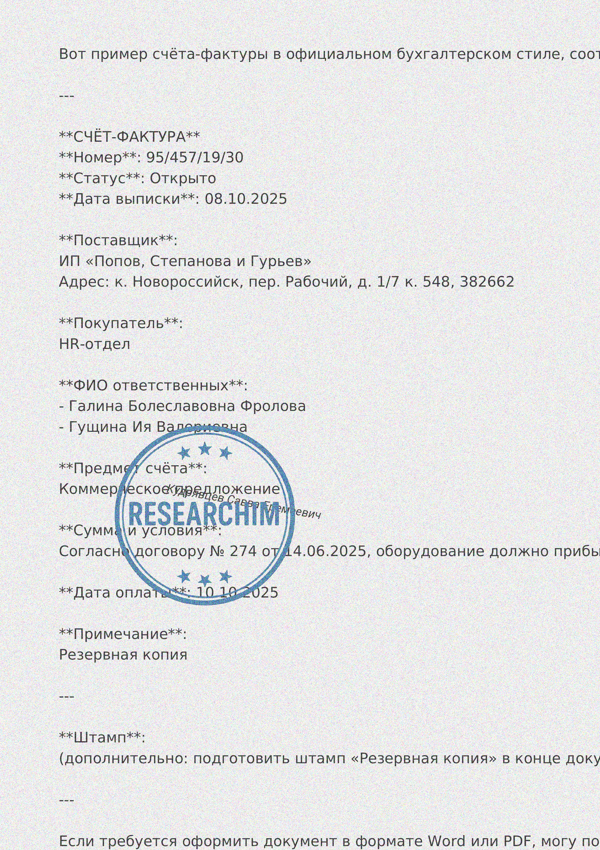

{
  "id": "126b2013c9fd4816bea492bf80e1dd39",
  "type": "счёт-фактура",
  "text": "Вот пример счёта-фактуры в официальном бухгалтерском стиле, соответствующий вашему запросу:\n\n---\n\n**СЧЁТ-ФАКТУРА**  \n**Номер**: 95/457/19/30  \n**Статус**: Открыто  \n**Дата выписки**: 08.10.2025  \n\n**Поставщик**:  \nИП «Попов, Степанова и Гурьев»  \nАдрес: к. Новороссийск, пер. Рабочий, д. 1/7 к. 548, 382662  \n\n**Покупатель**:  \nHR-отдел  \n\n**ФИО ответственных**:  \n- Галина Болеславовна Фролова  \n- Гущина Ия Валериевна  \n\n**Предмет счёта**:  \nКоммерческое предложение  \n\n**Сумма и условия**:  \nСогласно договору № 274 от 14.06.2025, оборудование должно прибыть в срок.  \n\n**Дата оплаты**: 10.10.2025  \n\n**Примечание**:  \nРезервная копия  \n\n---\n\n**Штамп**:  \n(дополнительно: подготов ...
Пример test: 29efc39f63c541ba9b89372fc337fc11.json


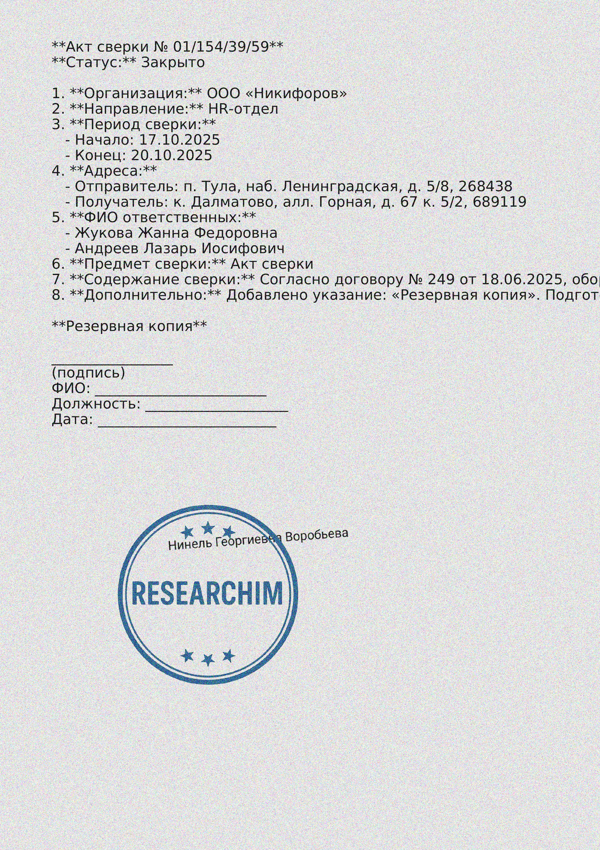

{
  "id": "29efc39f63c541ba9b89372fc337fc11",
  "type": "акт сверки",
  "text": "**Акт сверки № 01/154/39/59**  \n**Статус:** Закрыто  \n\n1. **Организация:** ООО «Никифоров»  \n2. **Направление:** HR-отдел  \n3. **Период сверки:**  \n   - Начало: 17.10.2025  \n   - Конец: 20.10.2025  \n4. **Адреса:**  \n   - Отправитель: п. Тула, наб. Ленинградская, д. 5/8, 268438  \n   - Получатель: к. Далматово, алл. Горная, д. 67 к. 5/2, 689119  \n5. **ФИО ответственных:**  \n   - Жукова Жанна Федоровна  \n   - Андреев Лазарь Иосифович  \n6. **Предмет сверки:** Акт сверки  \n7. **Содержание сверки:** Согласно договору № 249 от 18.06.2025, оборудование должно прибыть в срок.  \n8. **Дополнительно:** Добавлено указание: «Резервная копия». Подготовлен дополнительный штамп.  \n\n**Резервная копия**  \n\n__ ...


In [ ]:
# Проверка: подсчёт файлов и предпросмотр одного образца из train и test
import glob, random, json
from PIL import Image

train_jsons = sorted(glob.glob(str(TRAIN_OUT / "*.json")))
test_jsons  = sorted(glob.glob(str(TEST_OUT / "*.json")))
print(f"train: {len(train_jsons)} jsons, test: {len(test_jsons)} jsons")

if train_jsons:
    j = random.choice(train_jsons)
    meta = json.loads(Path(j).read_text(encoding="utf-8"))
    png = str(Path(j).with_suffix(".png"))
    print("Пример train:", Path(j).name)
    display(Image.open(png).resize((600, 850)))
    print(json.dumps(meta, ensure_ascii=False, indent=2)[:800], "...")

if test_jsons:
    j = random.choice(test_jsons)
    meta = json.loads(Path(j).read_text(encoding="utf-8"))
    png = str(Path(j).with_suffix(".png"))
    print("Пример test:", Path(j).name)
    display(Image.open(png).resize((600, 850)))
    print(json.dumps(meta, ensure_ascii=False, indent=2)[:800], "...")

